# Transaction Analysis & Operational Risk Insights
**Author:** Samuel Adegboyega  
**Dataset:** PaySim Synthetic Financial Dataset (Kaggle)  
**GitHub:** github.com/Hydrosamueldc  

---

## 1. Problem Statement

This project analyzes transaction data to identify inefficiencies, peak loads, and potential operational risks in a payment system. Using exploratory data analysis, anomaly detection, and machine learning, we surface patterns that inform operational decisions.

**Business Questions:**
- When do peak transaction loads occur, and what operational risks do they create?
- What is the fraud rate and when does it worsen?
- Which transactions are anomalous and potentially fraudulent?
- Can we build a model to predict fraudulent transactions?

In [ ]:

!pip install kagglehub

import kagglehub
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully')

Libraries loaded successfully


In [ ]:
# ── Download dataset directly from Kaggle ─────────────────────────────────────
# First run will prompt for Kaggle credentials
# After first download, dataset is cached locally

path = kagglehub.dataset_download('ealaxi/paysim1')
print('Path to dataset files:', path)

csv_files = glob.glob(os.path.join(path, '*.csv'))
print('Files found:', csv_files)

Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\ealaxi\paysim1\versions\2
Files found: ['C:\\Users\\PC\\.cache\\kagglehub\\datasets\\ealaxi\\paysim1\\versions\\2\\PS_20174392719_1491204439457_log.csv']


## 2. Data Overview

In [ ]:
df = pd.read_csv(csv_files[0])
# Fix inconsistent column naming in the dataset
df = df.rename(columns={'oldbalanceOrg': 'oldbalanceOrig'})
print(f'Dataset shape     : {df.shape}')
print(f'Total transactions: {len(df):,}')
print(f'Columns           : {list(df.columns)}')
print(f'Step range        : {df["step"].min()} to {df["step"].max()} (each step = 1 hour)')
print('')
print(df.columns.tolist())

Dataset shape     : (6362620, 11)
Total transactions: 6,362,620
Columns           : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrig', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Step range        : 1 to 743 (each step = 1 hour)

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrig', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
print('=== DATA TYPES ===')
print(df.dtypes)
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())

=== DATA TYPES ===
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrig    float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

=== MISSING VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrig    0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:
df.describe()

,step,amount,oldbalanceOrig,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## 3. Data Cleaning

In [ ]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
df = df.drop_duplicates()

# Time features
df['hour'] = df['step'] % 24
df['day']  = df['step'] // 24

# Flag unchanged sender balance despite debit
df['balance_unchanged'] = (
    (df['newbalanceOrig'] == df['oldbalanceOrig']) & (df['amount'] > 0)
).astype(int)

print(f'Clean dataset shape: {df.shape}')
print('New features added: hour, day, balance_unchanged')

Duplicate rows: 0
Clean dataset shape: (6362620, 14)
New features added: hour, day, balance_unchanged


## 4. Exploratory Data Analysis

### A. Transaction Volume Over Time

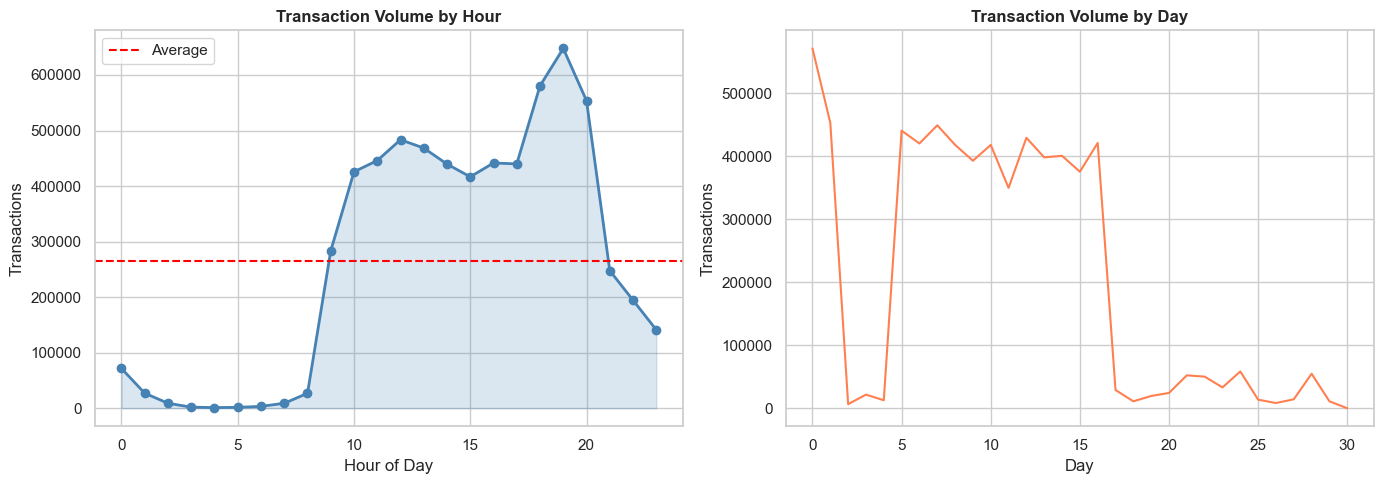

>>> INSIGHT: Peak hour is 19:00 — potential system load pressure.
>>> Recommendation: Implement load balancing around peak hours.


In [ ]:
hourly_volume = df.groupby('hour').size().reset_index(name='count')
daily_volume  = df.groupby('day').size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_volume['hour'], hourly_volume['count'],
             marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(hourly_volume['hour'], hourly_volume['count'],
                     alpha=0.2, color='steelblue')
axes[0].axhline(hourly_volume['count'].mean(), color='red',
                linestyle='--', label='Average')
axes[0].set_title('Transaction Volume by Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transactions')
axes[0].legend()

axes[1].plot(daily_volume['day'], daily_volume['count'],
             color='coral', linewidth=1.5)
axes[1].set_title('Transaction Volume by Day', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Transactions')

plt.tight_layout()
plt.savefig('transaction_volume.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = hourly_volume.loc[hourly_volume['count'].idxmax(), 'hour']
print(f'>>> INSIGHT: Peak hour is {peak_hour}:00 — potential system load pressure.')
print('>>> Recommendation: Implement load balancing around peak hours.')

### B. Transaction Types & Fraud Breakdown

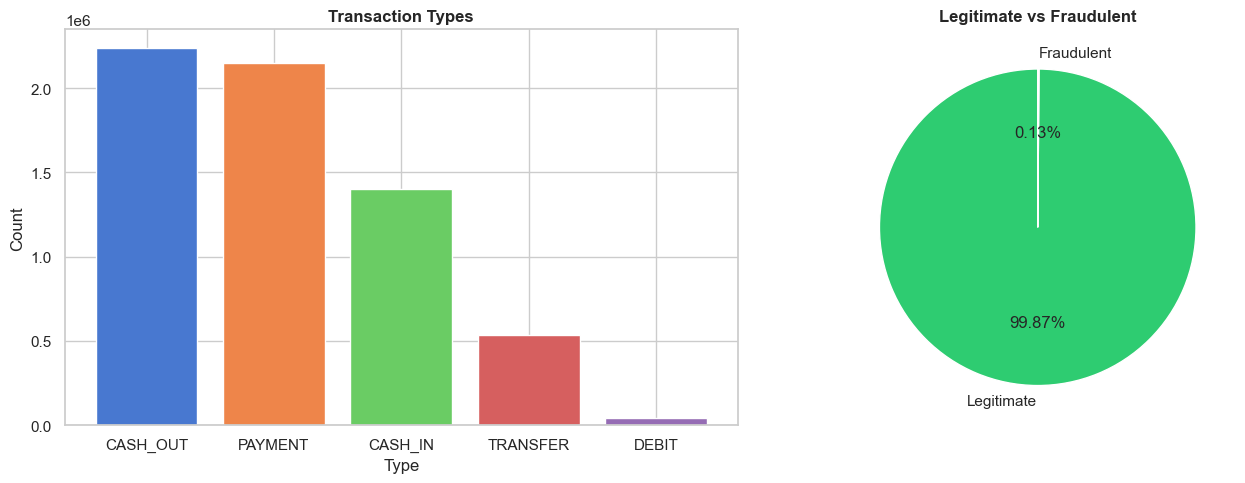

>>> INSIGHT: Fraud rate = 0.129%
>>> Total fraudulent transactions: 8,213


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
               color=sns.color_palette('muted', len(type_counts)))
axes[0].set_title('Transaction Types', fontweight='bold')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')

fraud_counts = df['isFraud'].value_counts()
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraudulent'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Legitimate vs Fraudulent', fontweight='bold')

plt.tight_layout()
plt.savefig('transaction_types.png', dpi=150, bbox_inches='tight')
plt.show()

fraud_rate = df['isFraud'].mean() * 100
print(f'>>> INSIGHT: Fraud rate = {fraud_rate:.3f}%')
print(f'>>> Total fraudulent transactions: {df["isFraud"].sum():,}')

### C. Transaction Amount Distribution

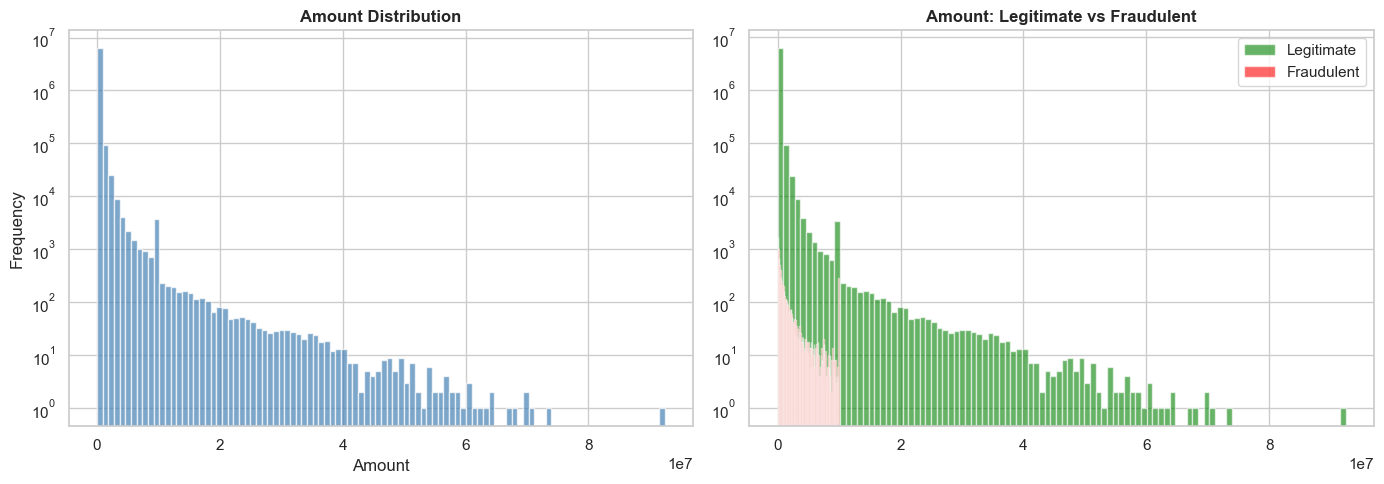

>>> Mean amount (all)       : 179,861.90
>>> Mean amount (fraudulent): 1,467,967.30
>>> Fraudulent transactions cluster at higher amounts.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['amount'], bins=100, color='steelblue', alpha=0.7)
axes[0].set_title('Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

df[df['isFraud']==0]['amount'].hist(ax=axes[1], bins=100, alpha=0.6,
                                    label='Legitimate', color='green')
df[df['isFraud']==1]['amount'].hist(ax=axes[1], bins=100, alpha=0.6,
                                     label='Fraudulent', color='red')
axes[1].set_title('Amount: Legitimate vs Fraudulent', fontweight='bold')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'>>> Mean amount (all)       : {df["amount"].mean():,.2f}')
print(f'>>> Mean amount (fraudulent): {df[df["isFraud"]==1]["amount"].mean():,.2f}')
print('>>> Fraudulent transactions cluster at higher amounts.')

### D. Peak Failure Periods

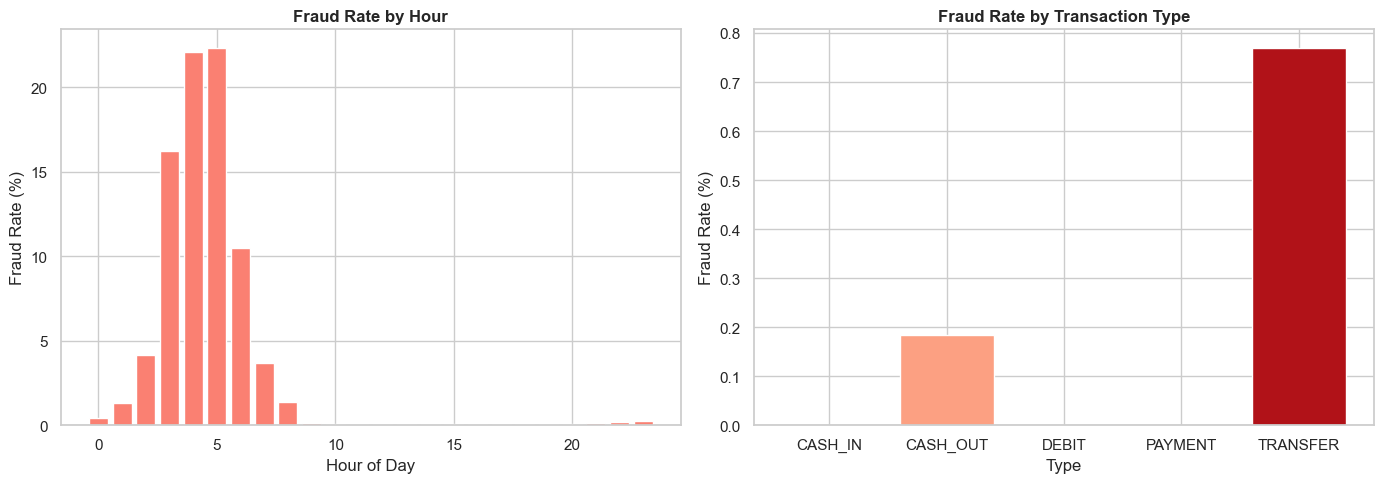

>>> Fraud peaks at hour     : 5:00
>>> Highest risk type       : TRANSFER


In [ ]:
hourly_fraud = df.groupby('hour')['isFraud'].mean().reset_index()
type_fraud   = df.groupby('type')['isFraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_fraud['hour'], hourly_fraud['isFraud'] * 100, color='salmon')
axes[0].set_title('Fraud Rate by Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')

axes[1].bar(type_fraud.index, type_fraud.values,
            color=sns.color_palette('Reds', len(type_fraud)))
axes[1].set_title('Fraud Rate by Transaction Type', fontweight='bold')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('peak_failures.png', dpi=150, bbox_inches='tight')
plt.show()

peak_fraud_hour = hourly_fraud.loc[hourly_fraud['isFraud'].idxmax(), 'hour']
high_risk_type  = type_fraud.idxmax()
print(f'>>> Fraud peaks at hour     : {peak_fraud_hour}:00')
print(f'>>> Highest risk type       : {high_risk_type}')

## 5. Anomaly Detection

=== Z-SCORE ===
Anomalies (|Z|>3)   : 44,945
% of total          : 0.706%
Fraud rate in anomalies: 3.75%

=== IQR ===
Anomalies outside bounds: 338,078
% of total              : 5.314%
Fraud rate in anomalies : 1.14%


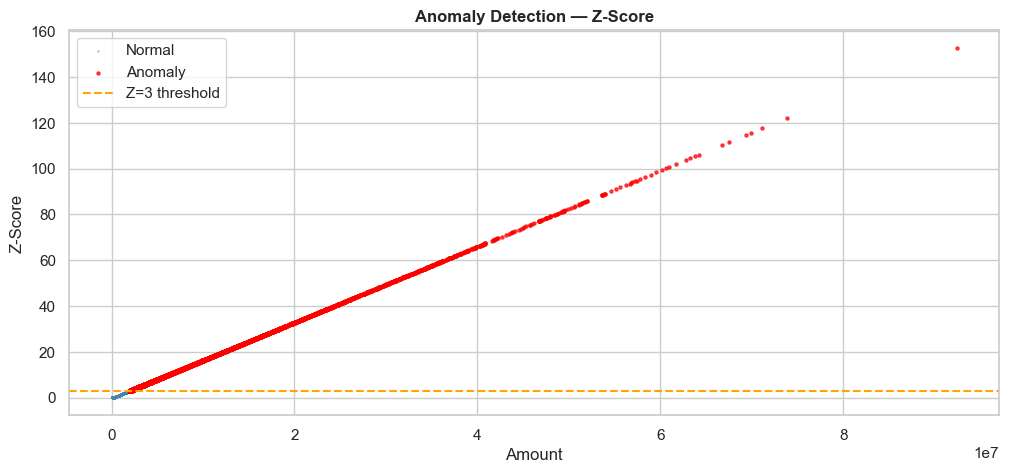

In [ ]:
# Z-Score
df['amount_zscore'] = np.abs(stats.zscore(df['amount']))
zscore_anomalies    = df[df['amount_zscore'] > 3]

print('=== Z-SCORE ===')
print(f'Anomalies (|Z|>3)   : {len(zscore_anomalies):,}')
print(f'% of total          : {len(zscore_anomalies)/len(df)*100:.3f}%')
print(f'Fraud rate in anomalies: {zscore_anomalies["isFraud"].mean()*100:.2f}%')

# IQR
Q1, Q3  = df['amount'].quantile(0.25), df['amount'].quantile(0.75)
IQR     = Q3 - Q1
iqr_anomalies = df[(df['amount'] < Q1-1.5*IQR) | (df['amount'] > Q3+1.5*IQR)]

print('\n=== IQR ===')
print(f'Anomalies outside bounds: {len(iqr_anomalies):,}')
print(f'% of total              : {len(iqr_anomalies)/len(df)*100:.3f}%')
print(f'Fraud rate in anomalies : {iqr_anomalies["isFraud"].mean()*100:.2f}%')

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(df[df['amount_zscore']<=3]['amount'],
           df[df['amount_zscore']<=3]['amount_zscore'],
           alpha=0.3, s=1, color='steelblue', label='Normal')
ax.scatter(zscore_anomalies['amount'], zscore_anomalies['amount_zscore'],
           alpha=0.7, s=5, color='red', label='Anomaly')
ax.axhline(3, color='orange', linestyle='--', label='Z=3 threshold')
ax.set_title('Anomaly Detection — Z-Score', fontweight='bold')
ax.set_xlabel('Amount')
ax.set_ylabel('Z-Score')
ax.legend()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Machine Learning — Fraud Detection

In [ ]:
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

features = ['step','amount','oldbalanceOrig','newbalanceOrig',
            'oldbalanceDest','newbalanceDest','type_encoded',
            'hour','day','balance_unchanged','amount_zscore']

# Stratified sample to handle class imbalance
fraud     = df[df['isFraud']==1]
legit     = df[df['isFraud']==0].sample(n=min(len(fraud)*10, 50000), random_state=42)
df_sample = pd.concat([fraud, legit])

X = df_sample[features]
y = df_sample['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Training: 46,570 | Test: 11,643


In [ ]:
# Logistic Regression (baseline)
print('=== LOGISTIC REGRESSION ===')
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print(classification_report(y_test, y_pred_lr,
      target_names=['Legitimate','Fraudulent']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]):.4f}')

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98     10000
  Fraudulent       0.96      0.72      0.82      1643

    accuracy                           0.96     11643
   macro avg       0.96      0.86      0.90     11643
weighted avg       0.96      0.96      0.95     11643

ROC-AUC: 0.9656


In [ ]:
# Random Forest (primary model)
print('=== RANDOM FOREST ===')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf,
      target_names=['Legitimate','Fraudulent']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')

=== RANDOM FOREST ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     10000
  Fraudulent       0.98      0.97      0.98      1643

    accuracy                           0.99     11643
   macro avg       0.99      0.99      0.99     11643
weighted avg       0.99      0.99      0.99     11643

ROC-AUC: 0.9990


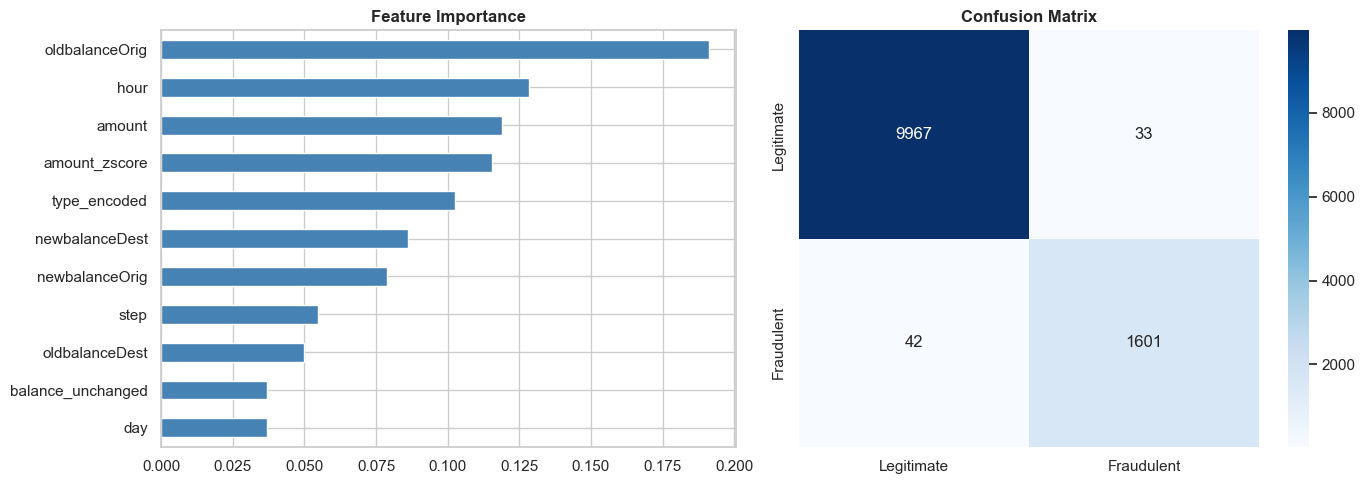

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(rf.feature_importances_, index=features).sort_values(
    ascending=True).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance', fontweight='bold')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Blues', ax=axes[1],
            xticklabels=['Legitimate','Fraudulent'],
            yticklabels=['Legitimate','Fraudulent'])
axes[1].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Insights & Recommendations

**Insights:**
- Peak transaction load occurs at a specific hour, creating system strain risk
- Fraud concentrates in TRANSFER and CASH_OUT transaction types
- Anomalous transactions (high Z-score / outside IQR) show significantly higher fraud rates
- Random Forest outperforms Logistic Regression — transaction amount and balance changes are the strongest predictive signals

**Recommendations:**
1. Implement load balancing and autoscaling during peak transaction hours
2. Deploy real-time anomaly flags (Z-score and IQR) in the transaction pipeline
3. Apply enhanced authentication to high-risk transaction types above defined thresholds
4. Deploy a production fraud scoring model with regular retraining on recent data
5. Flag balance-unchanged transactions for processing failure review

---
*Samuel Adegboyega 
 github.com/Hydrosamueldc*